- To download this notebook, click the download icon in the toolbar above and select the .ipynb format.  
- For any questions or comments, please open an issue on the [c4dynamics issues page](https://github.com/C4dynamics/C4dynamics/issues).  

# Vehicle Steering Control Using MPC

The notebook implements a Model Predictive Controller ($MPC$) for vehicle steering. Using a simplified model to track a straight reference line, it solves a constrained finite-horizon quadratic program at each time step with `scipy.optimize.minimze`, while simulating the closed-loop vehicle dynamics using [c4dynamics](https://github.com/c4dynamics/c4dynamics).


## Author

This notebook was developed by Gilmar Tuta ([@grep265](https://github.com/grep265)) as part of the c4dynamics project, under the guidance of the *c4dynamics maintainers*.

<div style="text-align: center;">
  <img src="lane_diagram.png" alt="alt text">
  <figcaption>Figure 1: Lane diagram: The steering command controls the vehicle in the lateral direction ($y$). The $MPC$ algorithm optimizes the cost over a finite dirction horizon in the forward (preview) direction.  
   </figcaption>
</div>


## 1. System Model

We consider a simplified kinematic model of a vehicle with 2 variables $[\psi ; y]$ `[1]`. See [Appendix for the linearization process](#Appendix).

$
\dot{\psi}(t) = \delta(t)
$

$
\dot{y}(t) = V \cdot \psi(t)
$

where:  
- $y$: lateral position $[m]$  
- $\psi$: heading angle $[rad]$  
- $V$: vehicle velocity $[m/s]$  
- $\delta$: steering input $[rad/s]$

Since the perturbation in $x$ is identically zero for a straight reference aligned with the $x$-axis, the $x$-state can be omitted from the perturbation dynamics without loss of information. 


### Control Objective
In this case, the primary goal is to follow a straight line at a constant velocity. The steering input $\delta$ is used to regulate the lateral position $\psi$ and the heading angle $y$. For straight-line tracking, the desired lateral position and heading angle are both zero.
In this example, we assume ideal measurements (i.e., zero noise) and focus mainly on the MPC logic. In practical applications, various sensors (e.g., IMU, GPS, wheel encoders) and/or a Kalman filter would be used to measure or estimate the lateral position and heading angle.

### Setup and Parameters

- Import required packages

In [1]:
import numpy as np
import c4dynamics as c4d
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

- Define vehicle speed, initial states, simulation step, and duration.

In [2]:
V = 22.3  # vehicle speed [m/s]

- Define initial states

In [3]:
psi0 = 0  # initial heading angle [rad]
y0 = 1    # initial lateral position [m]

- Define simulation step and duration

In [4]:
dt = 0.2   # time step [s]
t_end = 8  # simulation end time [s]

### Vehicle Model Function

In [5]:
def vehicle_model(t, x, delta, V=V):
    psi, y = x
    return [delta, V * psi]

### Initialize Vehicle State

Use `c4dynamics.state` to define and store the vehicle states during simulation:

In [6]:
vehicle = c4d.state(psi=psi0, y=y0)

Add steering input as a vehicle parameter:

In [7]:
vehicle.delta = 0

## 2. Model Predictive Controller (MPC)
The vehicle steering is controlled using a Model Predictive Controller. An $MPC$ algorith is composed by 3 core elements `[2]`:

1. `Prediction Model`: A mathematical representation of the system (typically discrete-time) used to predict future system behavior over a defined prediction horizon $N$. It enables the controller to anticipate how current actions affect future states.
2. `Cost Function`: A scalar function that quantifies desired performance, typically penalizing tracking error and control effort. The $MPC$ algorithm minimizes this function subject to constraints.
3. `Control Law`: Unlike traditional controllers with fixed gain formulas (e.g., $PID$), $MPC$ computes the control law by solving a constrained optimization problem in real-time. The solver generates an optimal sequence of future control inputs, but only the first input is applied to the plant. This receding-horizon process repeats at each time step.

$MPC$ is suitable for vehicle steering because it simultaneously addresses constraints, prediction, and optimization within a single control problem. Steering rate limits and actuator bounds can be enforced explicitly as constraints, ensuring physically feasible control actions. Unlike $PID$ controllers, which react only to tracking errors, $MPC$ optimizes a cost function over the prediction horizon, preventing the vehicle from entering unrecoverable states. This yields to smoother control actions and improved tracking performance, especially in constrained or highly dynamic scenarios.

For this case, the $MPC$ computes the optimal steering input $\delta$ over a finite prediction horizon to regulate both the lateral position $y$ and heading angle $\psi$ of the vehicle.

### 2.1 Prediction Model

 In a continuous system, motion is described by differential equations ($dx/dt$). The continuous-time kinematic model is:

$
\dot{\psi}(t) = \delta(t), \quad \dot{y}(t) = V \cdot \psi(t)
$

Computers and optimization solvers can't process a continuous "flow" of time. They require individual snapshots to do the math (discretization). Therefore, we break the motion into fixed time steps $dt$. This allows to predict the next state $x_{k+1}$ based on the current state $x_k$ and the control inputs $u_k$. The discrete model can be expressed as: $x_{k+1} = A \cdot x_k + B \cdot u_k$ `[3]`. For this example the timestep is $dt = 0.2 s$:

$
\psi_{k+1} = \psi_k + \delta_k \cdot  dt
$

$
y_{k+1} = y_k + V \cdot \psi_k \cdot dt + 0.5 \cdot V \cdot dt^2 \cdot \delta_k
$

This linear approximation allows the $MPC$ to "look ahead" into the future for a set number of steps (the horizon) to see where the car will end up before it actually moves.

In [8]:
A = np.array([
    [1.0, 0.0],
    [V * dt, 1.0]
])

B = np.array([
    [dt],
    [0.5 * V * dt**2]
])

Steering Input Constraint:

To ensure the simulation reflects real-world physics, we apply a hard constraint on the steering rate:$$|\delta| \le 1^\circ/\text{s}$$

This constraint represents the actuator limitation (specifically the steering rate limit). In a real vehicle, the steering actuation cannot change the wheel angle instantaneously. Limiting the rate of change prevents the controller from requesting commands beyond the actuator capabilities:

In [9]:
delta_max = 1 * c4d.d2r      # max steering rate [rad/s]

### 2.2. Cost Function

As stated earlier, the $MPC$ minimizes a finite-horizon cost function subject to constraints. 

The quadratic cost function penalizes state deviations through $Q$ and control effort through $R$:  

$$
J = x_N^T \cdot Q \cdot x_N + \overset{N-1}{\underset{k=0}{\sum}}{x_k^T \cdot Q \cdot x_k + u_k^T \cdot R \cdot u_k}
$$

Subject to the [Prediction Model](#2-prediction-model) and the steering constraint: 

$$
|\delta_k| \le \delta_{max}
$$

The term 
$ x_N^T \cdot Q \cdot x_N $
represents the terminal cost and is crucial for guaranteeing closed-loop stability and enabling optimization ofver a finite horizon. 


#### Optimization Method 

Since the problem is quadratic with linear constraints, it is a convex quadratic program.  
Here we solve it using a general-purpose constrained optimizer (SLSQP).

The problem is solved using `scipy.optimize.minimize` with the SLSQP (Sequential Least Squares Programming) algorithm.   
SLSQP is a gradient-based constrained optimizer.  
At each iteration, it linearizes the constratints and solves a quadratic subproblem to compute a search direction. 


#### Structure 

The optimizer takes: 

- 1 objective function:

	- **cost**: quadratic penalty on states and control inputs over the prediction horizon.

- 3 constraints functions: 

	- **initial_state**: enforces $X[:,0] = vehicle.X$.
	- **dynamics**: enforces the discrete-time linear model.
	- **control_bounds**: enforces $|\delta_k| <= \delta_{max}$.


#### Parameters

- **N**: prediction horizon   
- **Q**: state weighting   
- **R**: input weighting   

In [10]:
N = 20                      # prediction horizon
Q = np.diag([150.0, 1.0])   # weight on state variables [psi, y]
R = np.array([[1.0]])         # weight on input command [delta]

The relatively large weight $Q_\psi = 150$ compared to $Q_y = 1$ and $R = 1$ imposes a strong penalty on the heading error ($\psi$).  
This means the controller prioritizes reducing heading deviation quickly, even at the expense of increased control effort (subject to input constraints).  
The balance between the state weights and the input weight $R$, together with the steering constraint, shapes the transient response and limits excessive oscillation.

The cost function and the respective constraints are defined in the following snippet: 

In [11]:
def cost(z):
	"""
	cost function to minimize:
		X[N]'*Q*X[N] + sum[ X[k]'*Q*X[k] + u[k]'*R*u[k] ]
	"""

	X = z[:2*(N+1)].reshape(2, N+1)
	u = z[2*(N+1):].reshape(1, N)

	cost = 0
	for k in range(N):
		cost += X[:, k] @ Q @ X[:, k]
		cost += u[:, k] @ R @ u[:, k]
	cost += X[:, N] @ Q @ X[:, N]

	return cost


def initial_state(z):
	"""
	initial state constraints:
		X[:, 0] = vehicle.X
	"""
	X = z[:2*(N+1)].reshape(2, N+1)
	return X[:, 0] - vehicle.X


def dynamics(z):
	'''
	system dynamics:
		X[:, k+1] = A @ X[:, k] + B @ u[:, k]
	'''
	X = z[:2*(N+1)].reshape(2, N+1)
	u = z[2*(N+1):].reshape(1, N)

	constraints = []
	for k in range(N):
		error = X[:, k+1] - (A @ X[:, k] + B @ u[:, k])
		constraints.extend(error)
	return np.array(constraints)


def control_bounds(z):
	'''
	input control limits:
		|u[:, k]| <= delta_max
	'''
	u = z[2*(N+1):].reshape(1, N)
	return delta_max - np.abs(u).flatten()


constraints = [
    {'type': 'eq', 'fun': initial_state},
    {'type': 'eq', 'fun': dynamics},
    {'type': 'ineq', 'fun': control_bounds}
]



### 2.3. Control Law

The minimization function takes the current position and calculates the best sequence of steering moves to stay on track without going beyond physical limits (like max steering angle).  
The optimization returns the full optimal sequence, but only the first control action is applied to the vehicle.  


## 3. Simulation

The simulation workflow is illustrated below:

<div style='text-align: center;'>
  <img src='MPC_diagram.png' alt='alt text'>
</div>

At each time step:  

1. Store state and parameters 
1. Measure current state and solve $MPC$ for optimal steering input  
2. Apply the input and propagate the vehicle dynamics using `solve_ivp`  
3. Update and state

The control input is delayed by two time steps to allow the system to initialize smoothly and ensure reliable state measurements before closed-loop control is applied.

In [12]:
for ti in np.arange(0, t_end, dt):

    vehicle.store(ti)
    vehicle.storeparams('delta', t=ti)

    if ti >= 2 * dt:

        # Initial guess for optimization
        z0 = np.zeros(2*(N+1) + N)
        z0[:2*(N+1)] = np.tile(vehicle.X[:, np.newaxis], N+1).flatten()

        # solve the quadratic program once per step
        result = minimize(cost, z0, method='SLSQP',
                          constraints=constraints,
                          options={'ftol': 1e-6, 'maxiter': 100}
                          )

        # Extract first control input
        vehicle.delta = result.x[2*(N+1):].reshape(1, N)[0, 0]

    sol = solve_ivp(vehicle_model, [ti, ti + dt], vehicle.X, args=(vehicle.delta,))
    vehicle.X = sol.y[:, -1]


## 4. Results

- Lateral position $y$: moves from the initial offset toward zero.  
- Heading angle $\psi$: adjusts transiently to correct lateral error.  
- Steering input $\delta$: applies a bounded corrective action and settles near zero once stabilized.

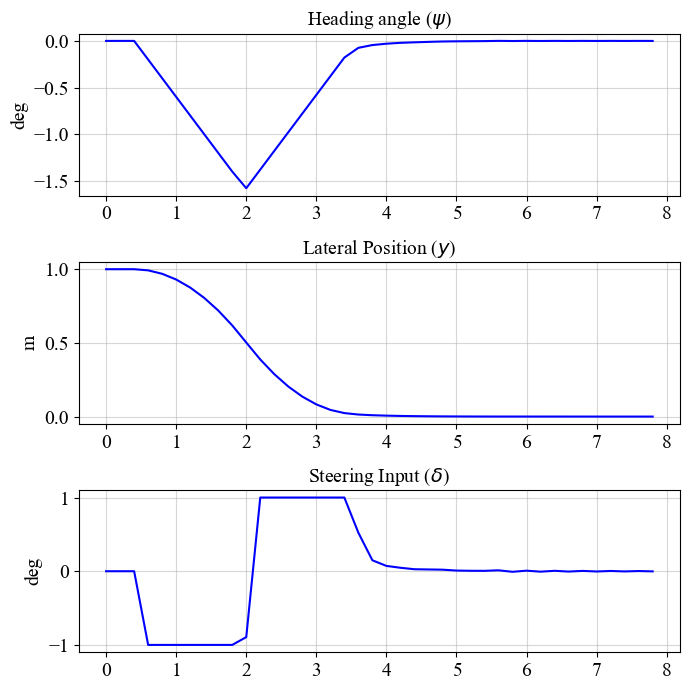

In [13]:
# plt.style.use('dark_background')
# Create a figure with 3 subplots
# fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True) #
fig, axs = plt.subplots(3, 1, figsize=(7, 7)) #
plt.subplots_adjust(right=0.8)

# 1. Heading Angle (psi) in degrees
axs[0].plot(*vehicle.data('psi', scale=c4d.r2d), color='blue', linewidth=1.5)
c4d.plotdefaults(axs[0], 'Heading angle ($\\psi$)', '', 'deg', fontsize = 14)

# 2. Lateral Position (y) in meters
axs[1].plot(*vehicle.data('y'), color='blue', linewidth=1.5)
c4d.plotdefaults(axs[1], 'Lateral Position ($y$)', '', 'm', fontsize = 14)

# 3. Steering Input (delta) in degrees
axs[2].plot(*vehicle.data('delta', scale=c4d.r2d), color='blue', linewidth=1.5)
c4d.plotdefaults(axs[2], 'Steering Input ($\\delta$)', '', 'deg', fontsize = 14)

plt.tight_layout()
# plt.show()

From the simulation results, it can be observed that the vehicle successfully tracks the desired path (straight line) after starting with an initial offset of $1 [m].$  
The lateral error decreases to zero over time.  
The steering input remains smooth and bounded without aggressive oscillations.

The triangular heading profile results from steering saturation ($\delta_{max} = 1 \text{deg/s} \rightarrow$ slope of $1\text{deg/s}$ in $\psi$).  
The large weight $Q_{\psi}$ encourages the controller to eliminate heading error rapidly, causing a bang-bang steering pattern under the input constraint.

These results highlight key $MPC$ characteristics:  
- The controller predicts future vehicle states and optimizes control actions accordingly.  
- Constraints on steering input are enforced through the optimization problem.  
- The receding horizon strategy ensures robustness to small modeling errors and disturbances by continuously updating the solution based on the current state.

## 5. Conclusions

This guide demonstrates the implementation of an $MPC$ for vehicle steering using a kinematic model. The controller was able to track a straight reference path while producing smooth and bounded steering commands.

By using a mathematical model of the vehicle, the controller predicts future states over a horizon and computes a sequence of steering actions that keep the vehicle on track in an optimal way. Unlike simpler controllers, $MPC$ accounts for physical limitations, such as maximum steering input, ensuring that all control actions remain feasible. By balancing multiple goals, like following a straight path while minimizing passenger discomfort (jerk), it achieves a sophisticated, human-like driving behavior.

Possible extensions of this work include:

- Using a more detailed vehicle model that captures tire forces, lateral slip, and dynamic effects
- Extending the controller to handle steering and longitudinal speed control simultaneously
- Introducing a state observer to estimate unmeasured variables for feedback control
- Implementing a nonlinear $MPC$ formulation for more complex scenarions, such as higher speeds or more aggressive maneuvers
- Replacing the analytical model with a neural network to develop a Neural $MPC$ controller

## References

[1] D. Gorinevsky Lecture notes: Stanford EE392M, Lecture 14: Model Predictive Control. [Online]. Available: https://web.stanford.edu/class/archive/ee/ee392m/ee392m.1056/Lecture14_MPC.pdf  
[2] E. F. Camacho and C. Bordons, “Model predictive control, ” in Advanced Textbooks in Control and Signal Processing. London, U.K., Springer, 2007.  
[3] J. B. Rawlings, D. Q. Mayne and M. M. Diehl, “Model Predictive Control: Theory, Computation, and Design, ” 2ed. Santa Barbara, U.S., Nob Hill, 2019.

# Appendix 
## Complete Linearization of a Planar Kinematic Model

In [System Model](#system-model) we presented the final form of the linear simplified representation of the system.  


The steps for a formal linearization:  

1. Write the nonlinear model
2. Choose an operating point
3. Define perturbation variables 
4. Compute Jacobians
5. Expand first-order Taylor series
6. Form the linear state-space model 
7. Validate the linearization

In this appendix we go step by step to linearize the planar kinematic of a vehicle about a straight-line reference trajectory. 

## 1. Nonlinear Continuous-Time Model

We consider a point mass moving in the plane with constant speed ($V$) and heading angle ($\psi$).  
The control input is the heading rate.
To avoid confusion with the approximation operator $\delta$, we use $u$ as the control input along the appendix. 

Precise nonlinear equations: 

$$
\begin{aligned}
\dot{x} = V \cdot \cos\psi \\
\dot{y} = V \cdot \sin\psi \\
\dot{\psi} = u
\end{aligned}
$$

where:  
- $x$: longitudinal position [m]
- $y$: lateral position [m]  
- $V$: vehicle velocity [m/s]  
- $ψ$: heading angle [rad]  
- $u$: steering input [rad/s]

State vector:  

$$
X = \begin{bmatrix} 
x & y & \psi 
\end{bmatrix}^T
$$


To linearize the system we have to define a reference trajectory, or operating point, about which the system is approximated. 

---


## 2. Reference Trajectory (Operating Point)

We linearize the system about a **straight-line motion** with constant heading ($\psi_r$) and zero control input.


$$
\begin{aligned}
\psi_r &= \text{const.} \\
u_r &= 0
\end{aligned}
$$

The corresponding reference trajectory $X_r$ is:


$$
\begin{aligned}
x_r(t) = V \cdot \cos\psi_r \cdot t \\
y_r(t) = V \cdot \sin\psi_r \cdot t \\
\psi_r(t) = \psi_r
\end{aligned}
$$


### Time Derivative of the Reference Trajectory

Differentiation of the reference trajectory gives: 
$$
\dot{X}_r =
\begin{bmatrix}
V \cdot \cos\psi_r \\
V \cdot \sin\psi_r \\
0
\end{bmatrix}
$$



### Consistency Check

Substituting $(\mathbf{X}_r, u_r)$ into the nonlinear model gives:


$$
\begin{aligned}
\dot{x} &= V \cdot \cos\psi_r \\
\dot{y} &= V \cdot \sin\psi_r \\
\dot{\psi} &= 0
\end{aligned}
$$

which matches $\dot{X}_r$.  
Thus, the reference is dynamically consistent.


The complete trajectory is therefore a construction of a straight line and a deviations part. 

Deviations from this reference trajectory can now be approximated by the linear parts of a Taylor series. 

---


## 3. Perturbation Variables

Define deviations $\delta{X}, \delta{u}$ from the reference trajectory:

$$
\begin{aligned}
\delta{X} = X - X_r  \\
\delta{u} = u - u_r  
\end{aligned}
$$

With time derivative:

$$
\dot{X} = \dot{X}_r + \delta \dot{X}
$$

These nonlinear deviations can be approximated by the first-order terms with in the Taylor expansion with respect to the state and the input deviations. 


![linearization](linearization.png)

---


## 4. First-Order Taylor Expansion

Let: 
$$
\dot{X} = f(X, u)
$$

A first-order Taylor expansion about $(X_r, u_r)$ yields (higher order terms are neglected): 

$$
\begin{aligned}

\dot{X} = \dot{X}_r + \delta \dot{X} \approx f(X_r, u_r)

+ \left.\frac{\partial f}{\partial X}\right|_{r} \cdot \Delta X
+ \left.\frac{\partial f}{\partial u}\right|_{r} \cdot \Delta u

\end{aligned}
$$

Since
$$
\dot{X}_r = f(X_r, u_r)
$$

the perturbation dynamics are

$$
\Delta \dot{X} = A \cdot \Delta X + B \cdot \Delta u
$$

Where:

- $\Delta \dot{X} \approx \delta \dot{X}$
- $A = \left.\frac{\partial f}{\partial X}\right|_{r}$  
- $B = \left.\frac{\partial f}{\partial u}\right|_{r}$

---


## 5. Jacobian Computation

$A$ and $B$ are given by the Jacobians, i.e., the partial derivatives of $f$ with respect to the state $X$ and with respect to the input $u$. 

### Jacobian with Respect to the State

$$
A = \left.\frac{\partial f}{\partial X}\right|_{X_r, u_r}
$$

Partial derivatives:

$$
\begin{aligned}

\frac{\partial \dot{x}} {\partial x}      = 0, &
\frac{\partial \dot{x}} {\partial y}      = 0, &
\frac{\partial \dot{x}} {\partial \psi} = -V \cdot \sin\psi_r \\

\frac{\partial \dot{y}} {\partial x}      = 0, &
\frac{\partial \dot{y}} {\partial y}      = 0, &
\frac{\partial \dot{y}} {\partial \psi} = V \cdot \cos\psi_r \\

\frac{\partial \dot{\psi}} {\partial x} = 0, &
\frac{\partial \dot{\psi}} {\partial y} = 0, &
\frac{\partial \dot{\psi}} {\partial \psi} = 0

\end{aligned}
$$

Thus

$$
A =
\begin{bmatrix}
0 & 0 & -V \cdot \sin\psi_r \\
0 & 0 &  V \cdot \cos\psi_r \\
0 & 0 & 0
\end{bmatrix}
$$



### Jacobian with Respect to the Input

$$
B = \left.\frac{\partial f}{\partial u}\right|_{X_r, u_r}
= \begin{bmatrix}
0 \\
0 \\
1
\end{bmatrix}
$$

---


## 6. Linearized Continuous-Time System

Substitution of the coefficients of $A$ and $B$ into the equation representation of the system: 

$$
\begin{aligned}
\Delta \dot{x} = -V \cdot \sin\psi_r \cdot \Delta \psi \\
\Delta \dot{y} =  V \cdot \cos\psi_r \cdot \Delta \psi \\
\Delta \dot{\psi} = \Delta u
\end{aligned}
$$

Recall that $\delta{X}$ represents the true nonlinear deviation, while $\Delta{X}$ denotes its first-order approximation used by the linear model.  
The physical interpretation of the coefficients in the linearized equations is as follows:  
- At first order, position deviations are caused only by heading perturbations. Velocity components aligned with the reference trajectory affect position only through higher-order terms.
- The tangent component (along the reference velocity) contributes only at second order, so it does not appear in the linearized $(\delta x, \delta y)$ equations.  
- The term $-V \cdot \sin\psi_r$ is the $x$-component of the normal component of the velocity deviation.  
- The term $V \cdot \cos\psi_r$ is the $y$-component of the normal component of the velocity deviation.


Define:

$$
\begin{aligned}
V_x = -V \cdot \sin\psi_r \\
V_y =  V \cdot \cos\psi_r
\end{aligned}
$$

Then:

$$
\begin{aligned}
\Delta \dot{x} = V_x \cdot \Delta \psi \\
\Delta \dot{y} = V_y \cdot \Delta \psi \\
\Delta \dot{\psi} = \Delta u
\end{aligned}
$$

This is the final linearized form of the a planar kinematic of a vehicle about a straight-line reference trajectory.  

### Notation Modification 

From this point onward, we redefine the perturbation variables $(\Delta{x} \rightarrow x,\Delta{y} \rightarrow y,\Delta{\psi} \rightarrow \psi)$ as the system state for notational simplicity.
Or simply: 

$$
\begin{aligned}
\dot{x} = V_x \cdot \psi \\
\dot{y} = V_y \cdot \psi \\
\dot{\psi} = u
\end{aligned}
$$


---


## 7. Zero-Heading Reference Simplification 

Now, let's assume the reference trajectory is parallel to the $x$ axis, i.e. $\psi_r = 0$.  

The linear model simplifies to:  

$$
\begin{aligned}
V_x = -V \cdot \sin 0 = 0 \\
V_y =  V \cdot \cos 0 = V  \\
\end{aligned}
$$

That is:

$$
\begin{aligned}
\dot{x} = 0 \\
\dot{y} = V \cdot \psi \\
\dot{\psi} = u
\end{aligned}
$$


Under this assumption the perturbation dynamics is as follows: 
- No motion in $x$ ($\dot{x} = 0$)
- The velocity in $y$ is simply the velocity angle ($\psi$) scaled by the velocity magnitude ($V$) 

Since the perturbation in $x$ is identically zero for a straight reference aligned with the $x$-axis, the $x$-state can be omitted from the perturbation dynamics without loss of information:

$$
\begin{aligned}
\dot{y} = V \cdot \psi \\
\dot{\psi} = u
\end{aligned}
$$

This simplified perturbation system is used by the $MPC$ optimizer to minimize deviations from the reference trajectory.  
However, for simulation of the vehicle dynamics, the complete state must be reconstructed as:

$$
\begin{aligned}
X = X_r + \Delta{X}
\end{aligned}
$$

Where $X_r$ is the reference dynamics: 


$$
\begin{aligned}
x_r(t) = V \cdot t  \\
y_r(t) = 0          \\
\psi_r(t) = 0
\end{aligned}
$$


And $\Delta{X}$ is the solution of the linearized dynamics. 

--- 


## 8. Discrete-Time Linear Model

Let's discretize the reference model and linearized model using forward Euler discretization with time-step ($dt$):

$$ 
\Delta X_{k+1} = (I + A \cdot dt) \cdot \Delta X_k + B \cdot dt \cdot \Delta u_k = F \cdot \Delta X_k + G \cdot \Delta u_k = 
$$


### Discrete-Time Linearized Model 


$$
F =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 &  V \cdot dt \\
0 & 0 & 1
\end{bmatrix},
\quad
G =
\begin{bmatrix}
0 \\
0 \\
dt
\end{bmatrix}
$$

For input $u$. 

### Discrete-Time Reference Model


$$
F_r =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix},
\quad
G_r =
\begin{bmatrix}
V \cdot dt \\
0 \\
0
\end{bmatrix}
$$

Where the reference input corresponds to constant forward velocity. 


---

## 9. Example 

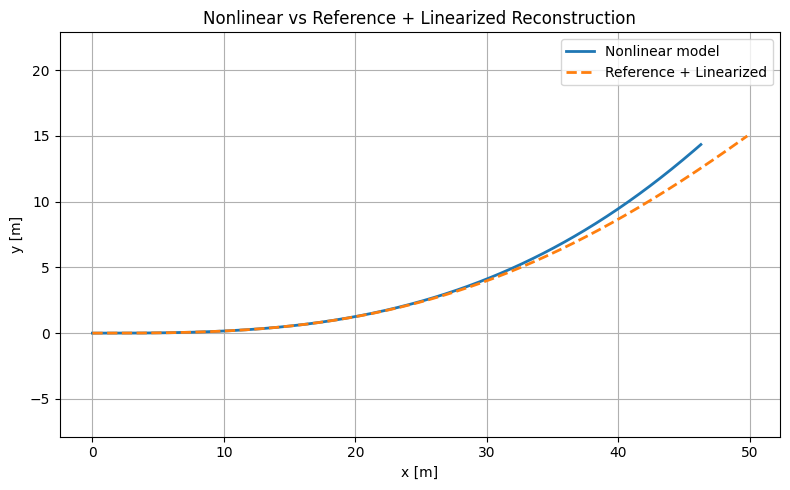

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import c4dynamics as c4d

# -----------------------------
# Parameters
# -----------------------------
V = 10.0          # [m/s]
dt = 0.01         # [s]
T  = 5.0          # [s]
N  = int(T / dt)

# Small steering input (heading rate)
def u(t):
  return 0.2 * np.sin(0.5 * t)

# Nonlinear system
nln_sys = c4d.state(x = 0.0, y = 0.0, psi = 0.0)

# Reference trajectory
ref_sys = c4d.state(x = 0.0, y = 0.0, psi = 0.0)

# Linearized model
lin_sys = c4d.state(y = 0.0, psi = 0.0)

for k in range(N - 1):
  t = k * dt
  nln_sys.store(t)
  ref_sys.store(t)
  lin_sys.store(t)

  # nonlinear system
  nln_sys.X += [V * np.cos(nln_sys.psi) * dt,
                V * np.sin(nln_sys.psi) * dt,
                u(t) * dt]

  # reference system
  ref_sys.X += [V * dt, 0, 0]

  # linear system
  lin_sys.X += [V * lin_sys.psi * dt,
                u(t) * dt]


# Reconstruct full state
x_rec = ref_sys.data('x')[1]
y_rec = ref_sys.data('y')[1] + lin_sys.data('y')[1]

# Plot
plt.figure(figsize = (8, 5))
plt.plot(nln_sys.data('x')[1], nln_sys.data('y')[1], label = "Nonlinear model", linewidth = 2)
plt.plot(x_rec, y_rec, "--", label = "Reference + Linearized", linewidth=2)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Nonlinear vs Reference + Linearized Reconstruction")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()
